In [1]:
import pandas as pd
import numpy as np
import os

###Step 2 – Describe Your Dataset


###Create a short document answering the following:
   1 .What is your data source?
   
   The data source is the House Price Prediction Dataset, which is provided as a CSV file for this project.

2.Why did you choose it?

We chose this dataset because it contains information about houses and their prices. It is suitable for practicing data extraction, cleaning, transformation, analysis, and report generation using Python and Pandas.

3. What information does it contain?

The dataset contains information about houses, including
Area,
Number of bedrooms,
Number of bathrooms,
Number of floors,
Year built,
Location,
Condition,
Garage,
Price,
ID of each house

4. Is the data structured, semi-structured, or unstructured?

The dataset is structured data because the information is organized into rows and columns. Each column represents a specific attribute of a house, and each row represents one house record.

5. What is the format of the data?

The data is available in CSV (Comma-Separated Values) format. CSV is a commonly used tabular data format that can be easily read and processed using Python and Pandas.

6. How frequently is the data updated?

The dataset is provided as a static CSV file for this project. The provided dataset does not specify a regular update frequency. Therefore, there is no specified daily, weekly, or monthly update schedule for this dataset.

#Step 3 – Design Your ETL Pipeline


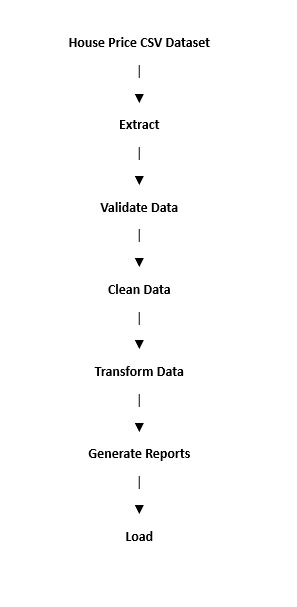

# Step 5
# Build the Extract Function


In [4]:
# extract
def extract():
    # 1. Connect to / read the chosen data source
    file_path ='/content/mini project'
    data = pd.read_csv('/content/Mini_Project/mini project/raw data/House Price Prediction Dataset.csv')

    # 2. Display number of records
    print("Number of records:",(data.shape[0]))

    # 3. Display number of columns
    print("Number of columns:", (data.shape[1]))
    return data




In [5]:
extract()

Number of records: 2000
Number of columns: 10


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


#Step 6  Build the Transform Function

In [6]:
#transform
def transform(data):
  # Check duplicate records
  print("Duplicate records:", data.duplicated().sum())

  # Remove duplicate records
  data = data.drop_duplicates()

  # Check again after removing
  print("Duplicate records after removal:", data.duplicated().sum())

  #2.# Check missing values
  print("Missing values before handling:")
  print(data.isnull().sum())
  data = data.rename(columns={
      'Id': 'House_ID',
      'Area': 'Area_sqft',
      'Bedrooms': 'Bedrooms',
      'Bathrooms': 'Bathrooms',
      'Floors': 'Floors',
      'YearBuilt': 'Year_Built',
      'Location': 'Location',
      'Condition': 'Condition',
      'Garage': 'Garage',
      'Price': 'Price'
  })

  # Display renamed columns
  print(data.columns)
  #4 remove unwanted colunms
  data = data.drop('House_ID', axis=1)
  print(data.columns)
  ##5 Change data types

  data.dtypes
  # Change data types
  data['Area_sqft'] = data['Area_sqft'].astype(float)
  data['Price'] = data['Price'].astype(float)

  print(data.dtypes)

  #6.Sort records
  data = data.sort_values(by='Price', ascending=False)

  print(data['Price'])
  #Filter records
  # Filter records based on Price
  filtered_data = data[data['Price'] > 500000]

  # Display filtered records
  print(filtered_data)
  # 8 Remove invalid values
  data = data[
      (data['Area_sqft'] > 0) &
      (data['Price'] > 0)
  ]

  print("Records after removing invalid values:", len(data))
  return data


# step 7  Generate reports


In [8]:
import os

def load(cleaned_data):
  # Create reports directory if it doesn't exist
  reports_dir = '/content/Mini_Project/reports'
  os.makedirs(reports_dir, exist_ok=True)

# 1. Complete cleaned dataset
  cleaned_data.to_csv(os.path.join(reports_dir, 'complete_cleaned_dataset.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'complete_cleaned_dataset.csv')}")

# 2. Top 10 records
  top_10_records = cleaned_data.head(10)
  top_10_records.to_csv(os.path.join(reports_dir, 'top_10_records.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'top_10_records.csv')}")

# 3. Summary statistics
  summary_stats = cleaned_data.describe()
  summary_stats.to_csv(os.path.join(reports_dir, 'summary_stats.csv'), index=False)

  print(f"Report saved: {os.path.join(reports_dir, 'summary_stats.csv')}")

#Step 9  Build the pipeline

In [9]:
def run_pipeline():
  raw_data = extract()
  cleaned_data = transform(raw_data)
  load(cleaned_data)



In [10]:
run_pipeline()

Number of records: 2000
Number of columns: 10
Duplicate records: 0
Duplicate records after removal: 0
Missing values before handling:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64
Index(['House_ID', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors',
       'Year_Built', 'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Year_Built',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
Area_sqft     float64
Bedrooms        int64
Bathrooms       int64
Floors          int64
Year_Built      int64
Location       object
Condition      object
Garage         object
Price         float64
dtype: object
1004    999656.0
1787    999453.0
1006    998128.0
1552    998084.0
241     997719.0
          ...   
1463     52024.0
1592     51845.0
1728     51082.0
836      50064.0
1167     50005.0
Name: 

In [11]:
cleaned_data = pd.read_csv('/content/Mini_Project/mini project/reports/complete_cleaned_dataset.csv')
cleaned_data.head()

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Location,Condition,Garage,Price
0,3099.0,1,2,3,1997,Suburban,Good,No,999656.0
1,566.0,4,1,1,1945,Urban,Fair,Yes,999453.0
2,736.0,3,2,3,1939,Downtown,Good,Yes,998128.0
3,2860.0,2,2,3,1910,Downtown,Fair,No,998084.0
4,2985.0,4,3,3,1969,Urban,Poor,Yes,997719.0


In [12]:
cleaned_data.dtypes

,0
Area_sqft,float64
Bedrooms,int64
Bathrooms,int64
Floors,int64
Year_Built,int64
Location,object
Condition,object
Garage,object
Price,float64


In [13]:
cleaned_data.describe()

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [14]:
cleaned_data.nunique()

,0
Area_sqft,1622
Bedrooms,5
Bathrooms,4
Floors,3
Year_Built,124
Location,4
Condition,4
Garage,2
Price,1999


In [15]:
cleaned_data.isna().sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Floors,0
Year_Built,0
Location,0
Condition,0
Garage,0
Price,0


#Outliers

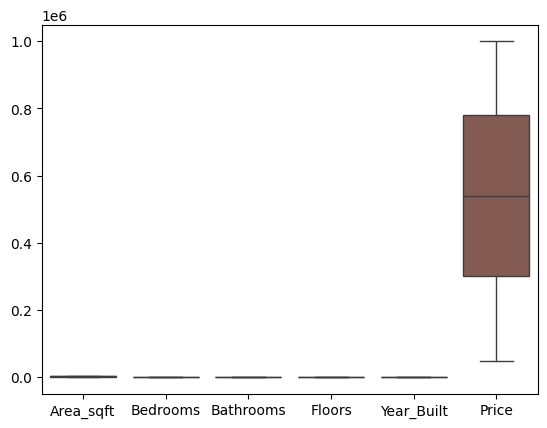

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(cleaned_data)
plt.show()

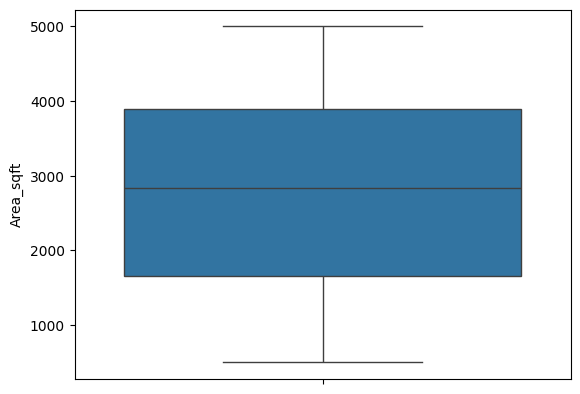

In [17]:
sns.boxplot(cleaned_data['Area_sqft'])
plt.show()

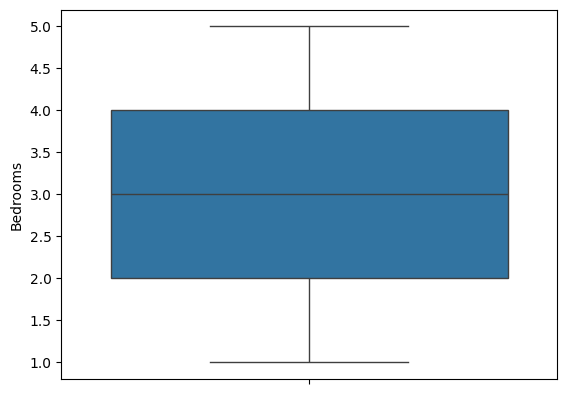

In [18]:
sns.boxplot(cleaned_data['Bedrooms'])
plt.show()

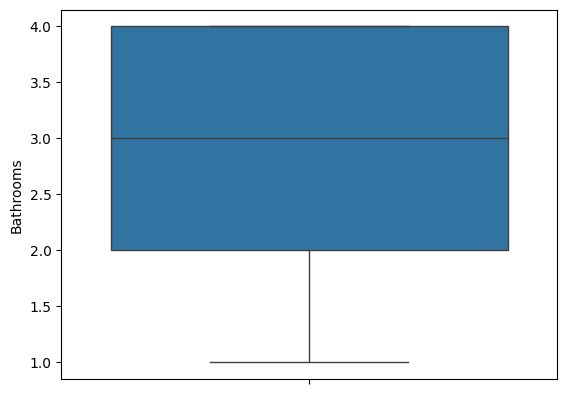

In [19]:
sns.boxplot(cleaned_data['Bathrooms'])
plt.show()

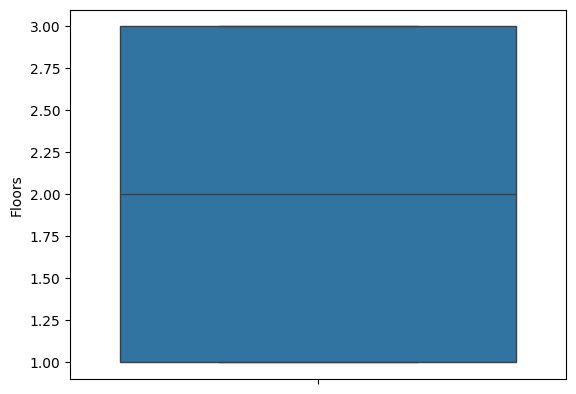

In [20]:
sns.boxplot(cleaned_data['Floors'])
plt.show()

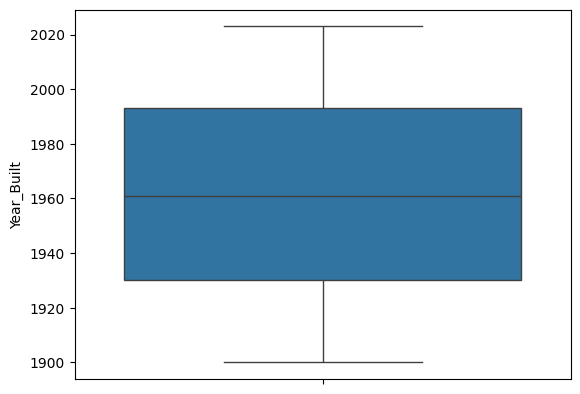

In [21]:
sns.boxplot(cleaned_data['Year_Built'])
plt.show()

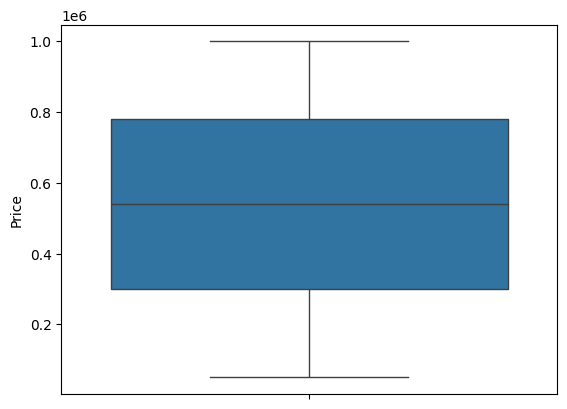

In [22]:
sns.boxplot(cleaned_data['Price'])
plt.show()

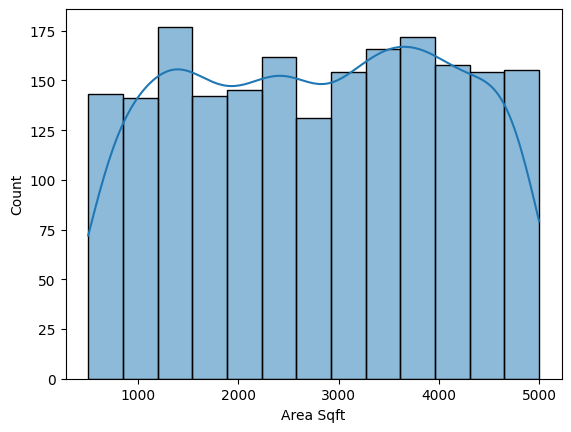

In [23]:
sns.histplot(cleaned_data['Area_sqft'],kde = True)
plt.xlabel('Area Sqft')
plt.show()

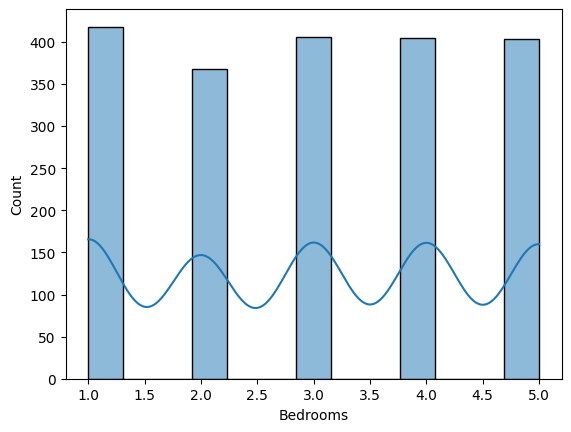

In [24]:
sns.histplot(cleaned_data['Bedrooms'],kde = True)
plt.xlabel('Bedrooms')
plt.show()

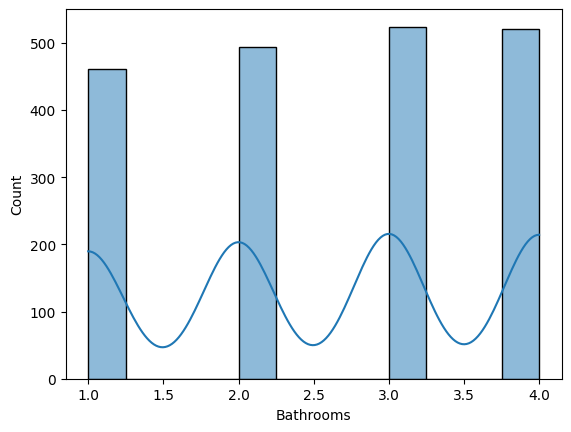

In [25]:
sns.histplot(cleaned_data['Bathrooms'],kde = True)
plt.xlabel('Bathrooms')
plt.show()

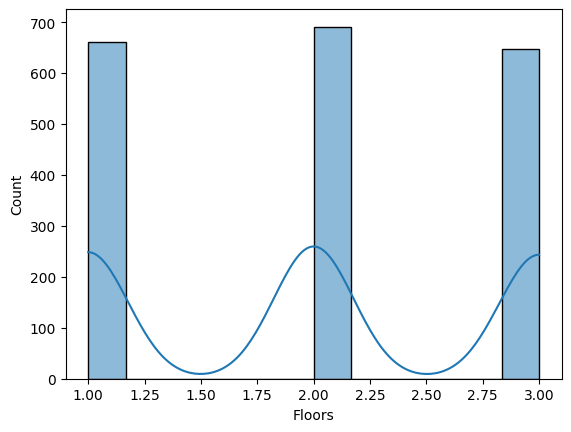

In [26]:
sns.histplot(cleaned_data['Floors'],kde = True)
plt.xlabel('Floors')
plt.show()

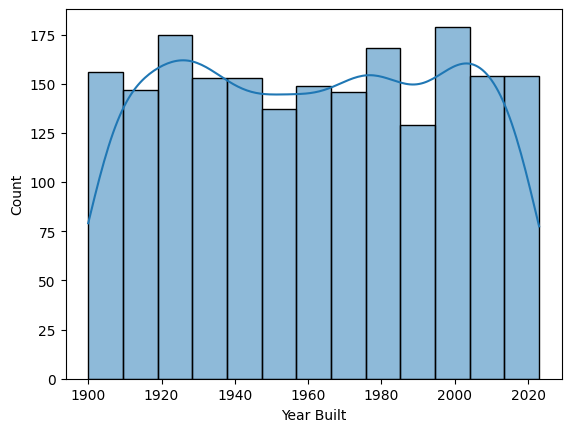

In [27]:
sns.histplot(cleaned_data['Year_Built'],kde = True)
plt.xlabel('Year Built')
plt.show()

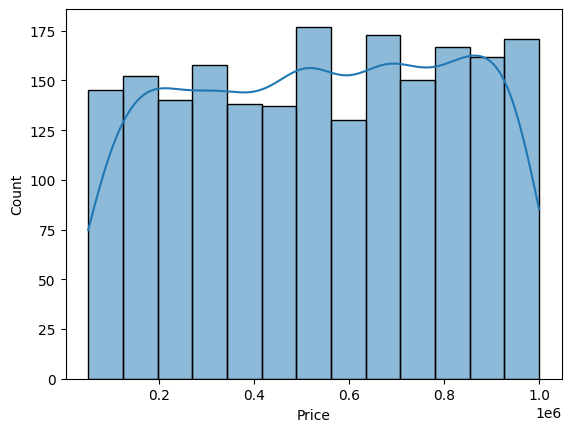

In [28]:
sns.histplot(cleaned_data['Price'],kde = True)
plt.xlabel('Price')
plt.show()

In [29]:
cleaned_data['Garage'].value_counts()

,count
Garage,
No,1038
Yes,962


In [30]:
cleaned_data['Location'].value_counts()

,count
Location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [31]:
cleaned_data['Condition'].value_counts()

,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


##Ordinal Encoding

In [32]:
cleaned_data['Condition'].unique()

array(['Good', 'Fair', 'Poor', 'Excellent'], dtype=object)

In [33]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(
    categories = [['Poor', 'Fair', 'Good', 'Excellent']]
)
cleaned_data['Condition'] = encoder.fit_transform(cleaned_data[['Condition']])

In [34]:
cleaned_data.head()

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Location,Condition,Garage,Price
0,3099.0,1,2,3,1997,Suburban,2.0,No,999656.0
1,566.0,4,1,1,1945,Urban,1.0,Yes,999453.0
2,736.0,3,2,3,1939,Downtown,2.0,Yes,998128.0
3,2860.0,2,2,3,1910,Downtown,1.0,No,998084.0
4,2985.0,4,3,3,1969,Urban,0.0,Yes,997719.0


#Binary Encoding

In [35]:
cleaned_data['Garage'] = cleaned_data['Garage'].map({
    'No':0,
   'Yes':1
 })

In [36]:
cleaned_data.head()

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Location,Condition,Garage,Price
0,3099.0,1,2,3,1997,Suburban,2.0,0,999656.0
1,566.0,4,1,1,1945,Urban,1.0,1,999453.0
2,736.0,3,2,3,1939,Downtown,2.0,1,998128.0
3,2860.0,2,2,3,1910,Downtown,1.0,0,998084.0
4,2985.0,4,3,3,1969,Urban,0.0,1,997719.0


#One Hot Encoding

In [37]:
cleaned_data = pd.get_dummies(cleaned_data,dtype = 'int')
cleaned_data


,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Price,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban
0,3099.0,1,2,3,1997,2.0,0,999656.0,0,0,1,0
1,566.0,4,1,1,1945,1.0,1,999453.0,0,0,0,1
2,736.0,3,2,3,1939,2.0,1,998128.0,1,0,0,0
3,2860.0,2,2,3,1910,1.0,0,998084.0,1,0,0,0
4,2985.0,4,3,3,1969,0.0,1,997719.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4138.0,3,4,1,1960,1.0,0,52024.0,0,0,0,1
1996,4368.0,5,4,2,1976,1.0,0,51845.0,1,0,0,0
1997,509.0,4,1,2,1993,1.0,0,51082.0,0,0,0,1
1998,2871.0,4,2,1,1914,0.0,0,50064.0,0,0,1,0


# splitting dependent feature and independent feature

In [39]:
x = cleaned_data.drop(['Price'],axis = 1)
y = cleaned_data['Price']

In [40]:
x

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban
0,3099.0,1,2,3,1997,2.0,0,0,0,1,0
1,566.0,4,1,1,1945,1.0,1,0,0,0,1
2,736.0,3,2,3,1939,2.0,1,1,0,0,0
3,2860.0,2,2,3,1910,1.0,0,1,0,0,0
4,2985.0,4,3,3,1969,0.0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,4138.0,3,4,1,1960,1.0,0,0,0,0,1
1996,4368.0,5,4,2,1976,1.0,0,1,0,0,0
1997,509.0,4,1,2,1993,1.0,0,0,0,0,1
1998,2871.0,4,2,1,1914,0.0,0,0,0,1,0


In [41]:
y

,Price
0,999656.0
1,999453.0
2,998128.0
3,998084.0
4,997719.0
...,...
1995,52024.0
1996,51845.0
1997,51082.0
1998,50064.0


#Train Test Split

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size = 0.2,random_state = 42
)

In [43]:
x_train

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban
968,3835.0,2,4,3,2019,2.0,1,0,0,0,1
240,2414.0,5,2,2,2012,1.0,0,0,1,0,0
819,4926.0,1,4,2,1975,1.0,1,1,0,0,0
692,689.0,5,1,3,1900,3.0,1,0,0,0,1
420,3916.0,3,4,1,1973,1.0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1130,3266.0,2,1,1,1913,3.0,1,0,0,1,0
1294,4768.0,2,3,1,1908,3.0,0,0,1,0,0
860,4526.0,5,1,1,2009,1.0,1,0,0,0,1
1459,1450.0,4,3,3,1942,1.0,1,1,0,0,0


In [44]:
x_test

,Area_sqft,Bedrooms,Bathrooms,Floors,Year_Built,Condition,Garage,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban
1860,1306.0,4,3,1,1932,0.0,0,0,1,0,0
353,3652.0,4,4,2,1935,1.0,1,1,0,0,0
1333,2496.0,5,1,1,1963,2.0,0,1,0,0,0
905,707.0,3,1,2,1953,3.0,0,0,0,1,0
1289,2969.0,1,3,2,2004,3.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
965,3056.0,5,2,2,1949,0.0,0,0,0,0,1
1284,1198.0,4,1,3,2002,2.0,0,0,0,1,0
1739,3728.0,5,1,3,2007,0.0,0,0,0,0,1
261,2893.0,2,1,3,1948,1.0,1,1,0,0,0


In [45]:
y_train

,Price
968,553575.0
240,895383.0
819,636056.0
692,688668.0
420,818026.0
...,...
1130,487744.0
1294,401301.0
860,614562.0
1459,320114.0


In [46]:
y_test

,Price
1860,118607.0
353,845016.0
1333,385206.0
905,589677.0
1289,404820.0
...,...
965,555533.0
1284,406043.0
1739,178145.0
261,886048.0


#Scaling - Standard **Scaling**

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [48]:
x_train_scaled

array([[ 0.78243806, -0.73148895,  1.3009439 , ..., -0.54653573,
        -0.57350122,  1.74954671],
       [-0.31204653,  1.38493477, -0.49811422, ...,  1.82970656,
        -0.57350122, -0.57157662],
       [ 1.62274959, -1.43696352,  1.3009439 , ..., -0.54653573,
        -0.57350122, -0.57157662],
       ...,
       [ 1.31466103,  1.38493477, -1.39764327, ..., -0.54653573,
        -0.57350122,  1.74954671],
       [-1.05453994,  0.6794602 ,  0.40141484, ..., -0.54653573,
        -0.57350122, -0.57157662],
       [ 1.07820307, -0.02601437,  0.40141484, ..., -0.54653573,
         1.74367544, -0.57157662]])

#Before and After Scaling

In [49]:
print('Before scaling')
print(x_train.head())

Before scaling
     Area_sqft  Bedrooms  Bathrooms  Floors  Year_Built  Condition  Garage  \
968     3835.0         2          4       3        2019        2.0       1   
240     2414.0         5          2       2        2012        1.0       0   
819     4926.0         1          4       2        1975        1.0       1   
692      689.0         5          1       3        1900        3.0       1   
420     3916.0         3          4       1        1973        1.0       1   

     Location_Downtown  Location_Rural  Location_Suburban  Location_Urban  
968                  0               0                  0               1  
240                  0               1                  0               0  
819                  1               0                  0               0  
692                  0               0                  0               1  
420                  0               1                  0               0  


In [50]:
print('After Scaling')
print(x_train_scaled[:5])

After Scaling
[[ 0.78243806 -0.73148895  1.3009439   1.25593537  1.59593089  0.45507117
   1.04605967 -0.61781273 -0.54653573 -0.57350122  1.74954671]
 [-0.31204653  1.38493477 -0.49811422  0.01012223  1.40244493 -0.44162079
  -0.95596841 -0.61781273  1.82970656 -0.57350122 -0.57157662]
 [ 1.62274959 -1.43696352  1.3009439   0.01012223  0.37973346 -0.44162079
   1.04605967  1.61861345 -0.54653573 -0.57350122 -0.57157662]
 [-1.64067841  1.38493477 -1.39764327  1.25593537 -1.69333033  1.35176312
   1.04605967 -0.61781273 -0.54653573 -0.57350122  1.74954671]
 [ 0.84482599 -0.02601437  1.3009439  -1.23569091  0.32445176 -0.44162079
   1.04605967 -0.61781273  1.82970656 -0.57350122 -0.57157662]]


#Visualisation

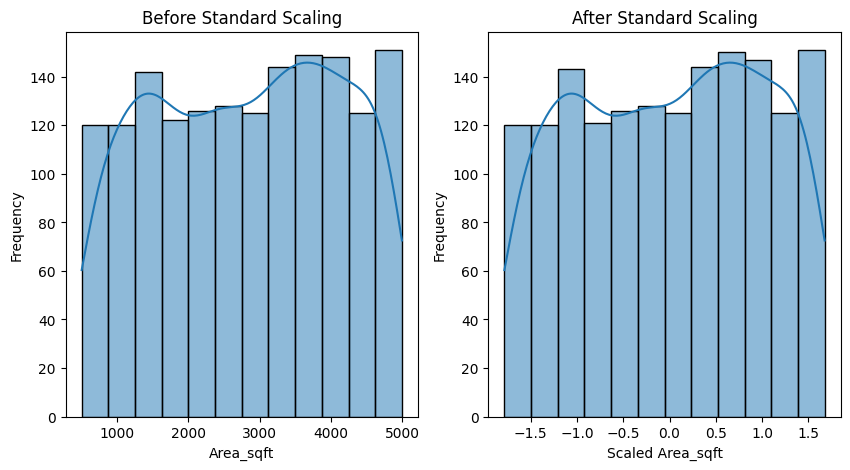

In [52]:
plt.figure(figsize =(10,5))
#Before Scaling
plt.subplot(1,2,1)
sns.histplot(x_train['Area_sqft'], kde = True)
plt.title('Before Standard Scaling')
plt.xlabel('Area_sqft')
plt.ylabel('Frequency')

# After Scaling
plt.subplot(1,2,2)
sns.histplot(x_train_scaled[: , 0], kde = True)
plt.title('After Standard Scaling')
plt.xlabel('Scaled Area_sqft')
plt.ylabel('Frequency')

plt.tight_layout
plt.show()